# Parametric imaging viewer

Uses your original plotting function, mask ordering, colour scale and orientation. Run the cells below to display the **Kᵢ posterior mean** and save a PNG. This retains the original assumption that prediction order matches `mask_slice == 1`; it does not require geometry verification flags.

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, median_filter, gaussian_filter

%matplotlib inline

# Open this notebook from LoRACM/ or LoRACM/notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

PREDICTIONS = ROOT / 'runs/scenario1/predictions.npz'
MASK = ROOT / 'data/real/Sub001_slice75_mask.npy'
SAVE_PATH = ROOT / 'runs/scenario1/Ki_mean.png'


In [7]:
def parametric_map_interactive(para_array, mask_slice, ratio, parameter_name, cbar=True, save_path=None):
    para_map = np.zeros_like(mask_slice, dtype=float)
    para_map[mask_slice == 1] = para_array
    index_map = np.zeros_like(mask_slice, dtype=int)
    index_map[mask_slice == 1] = np.arange(len(para_array))
    
    #     --- START: Median Filtering ---
    
    # Define the neighborhood size. 
    # size=3 means a 3x3 kernel (looks at 8 neighbors).
    # size=5 means a 5x5 kernel (stronger effect). Start with 3.
    kernel_size = 2

    # Apply the median filter
    para_map = median_filter(para_map, size=kernel_size)
    
    # Re-apply the original mask to ensure no values "bleed" into the background
    para_map[mask_slice == 0] = 0.0
    
#     --- END: Median Filtering ---
    
    
    fig, ax = plt.subplots(figsize=(6, 10))
    cmap = 'gray'
    if parameter_name == 'Ki':
        vmax = 0.06
        cmap = plt.cm.inferno
    elif parameter_name == 'Ki Uncertainty':
        vmax = 0.12
        cmap = plt.cm.inferno
    elif parameter_name == 'Ki Posterior Std':
        vmax = 0.03
        cmap = plt.cm.inferno
    elif parameter_name == 'K_1':
        vmax = 0.9
        cmap = plt.cm.inferno
    elif parameter_name == 'Vb':
        vmax = np.max(para_map)
    elif parameter_name == 'k_4':
        vmax = 0.125
        cmap = plt.cm.inferno
    elif parameter_name == 'k_2':
        vmax = 1.8
        cmap = plt.cm.inferno
    elif parameter_name == 'k_3':
        vmax = 0.3
        cmap = plt.cm.inferno
    elif parameter_name == 'EDT':
        vmax = 40
    elif parameter_name == 'Patlak Ki':
        vmax = 0.09
        cmap = plt.cm.inferno
    elif parameter_name == 'Logan VT':
        vmax = 4
    elif parameter_name == 'Coefficient of Variation':
        vmax = np.max(para_map)
        cmap = plt.cm.inferno
    elif parameter_name == 'k4 Irreversibility':
        vmax = np.max(para_map)
        cmap = plt.cm.binary
    else:
        vmax = np.max(para_map)
    vmin = np.min(para_map)
    img_overlay = ax.imshow(para_map, cmap=cmap, alpha=1, aspect=ratio, vmax=vmax, vmin=vmin, interpolation='nearest')
    img_overlay.set_clim(0, vmax)
    plt.axis('off')
    ax.invert_yaxis()
    if cbar:
        cbar = plt.colorbar(img_overlay, ax=ax, orientation='vertical')
        cbar.set_label('{}'.format(parameter_name), fontsize=30, fontname='Arial')
        cbar.ax.tick_params(labelsize=16)

    def format_coord(x, y):
        """Given float x,y in data coords, convert to row, col, then lookup."""
        col = int(np.round(x))
        row = int(np.round(y))
        nrows, ncols = para_map.shape
        if 0 <= row < nrows and 0 <= col < ncols:
            mask_val = mask_slice[row, col]
            if mask_val:
                idx = index_map[row, col]
                val = para_map[row, col]
                return f'x={col}, y={row}   para_array index={idx}   value={val:.4g}'
        return f'x={col}, y={row}'
    ax.format_coord = format_coord
    if save_path is not None:
        fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show()

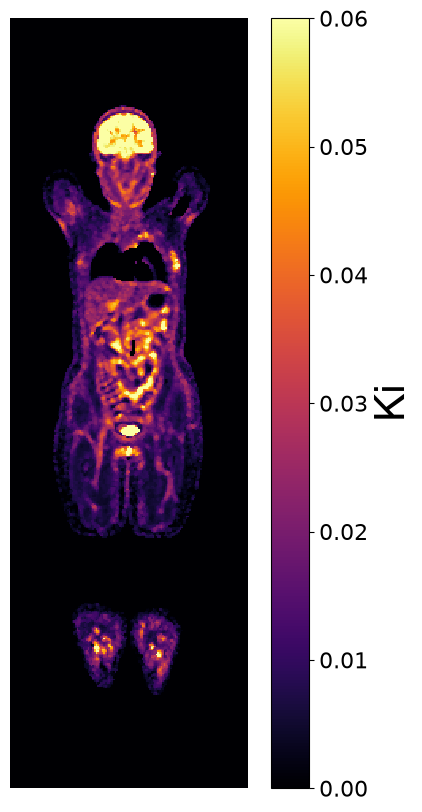

Saved: /Users/golfgti/Downloads/PET-TRACER-main/LoRACM/runs/scenario1/Ki_mean.png


In [8]:
# Load the released 2D slice mask (the original mask[:, 75, :]).
mask_slice = np.load(MASK, allow_pickle=False)
with np.load(PREDICTIONS, allow_pickle=False) as estimates:
    statistic = estimates['Ki_mean'].copy()

if mask_slice.ndim != 2 or statistic.ndim != 1:
    raise ValueError('Expected a 2D slice mask and a 1D Ki array.')
if np.count_nonzero(mask_slice == 1) != len(statistic):
    raise ValueError('Prediction count does not match the mask. Run inference for the complete slice without --max-voxels.')

SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
parametric_map_interactive(statistic, mask_slice, ratio=1,
                          parameter_name='Ki', save_path=SAVE_PATH)
print(f'Saved: {SAVE_PATH}')
